In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f"Dimension of the training set: {train.shape}")
print(f"Dimension of the testing set: {test.shape}")

Dimension of the training set: (1460, 81)
Dimension of the testing set: (1459, 80)


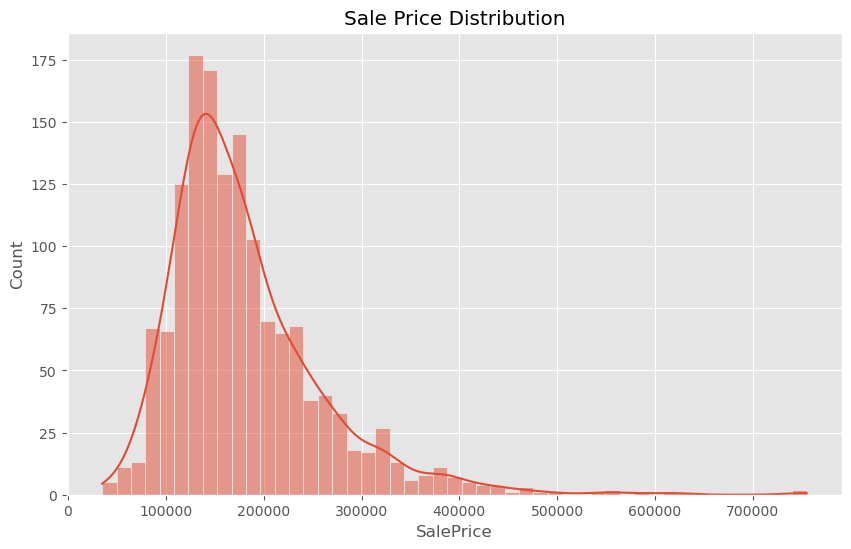

Skewness value: 1.88


In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(train['SalePrice'], kde=True)
plt.title('Sale Price Distribution')
plt.show()

print(f"Skewness value: {train['SalePrice'].skew():.2f}")

Skewness value: -0.01


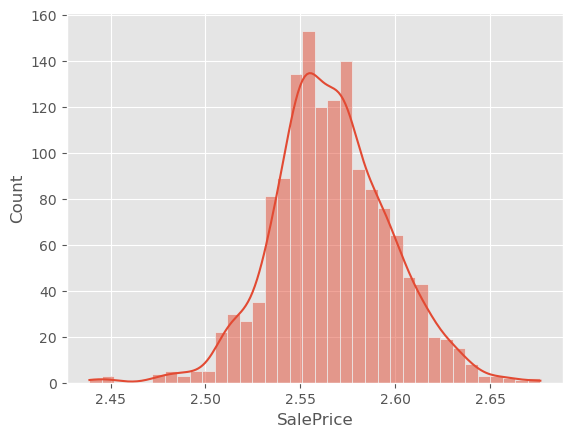

In [12]:
train["SalePrice"] = np.log1p(train["SalePrice"])

print(f"Skewness value: {train['SalePrice'].skew():.2f}")

sns.histplot(train['SalePrice'], kde=True)
plt.show()

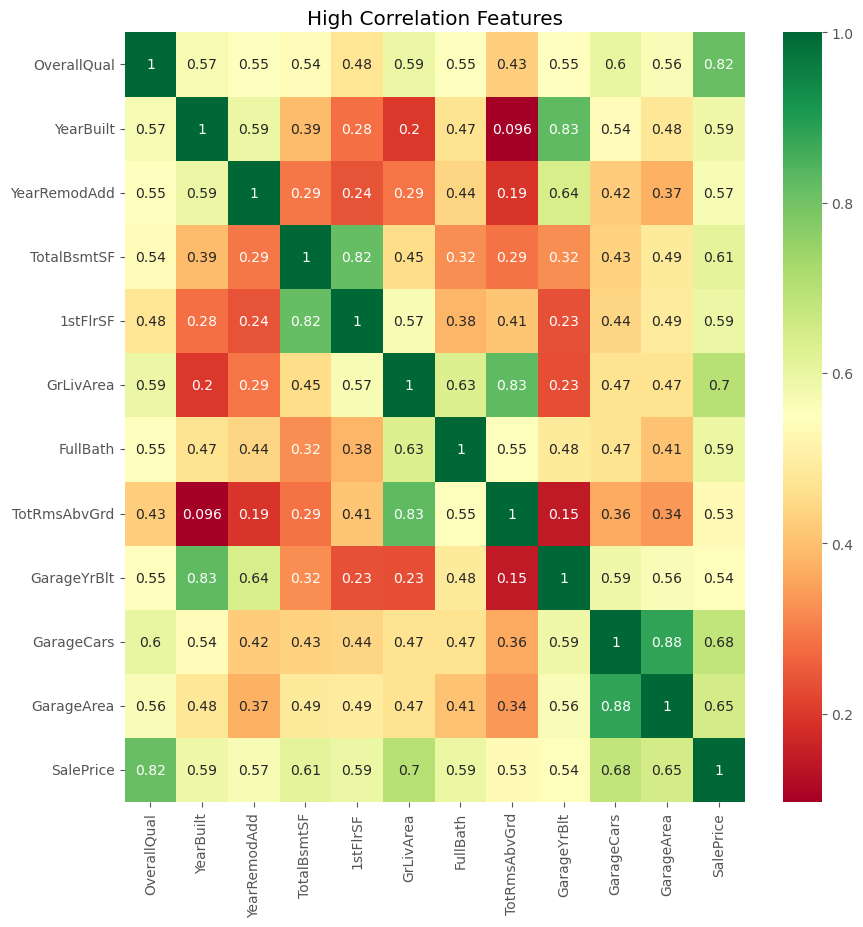

In [13]:
corrmat = train.corr(numeric_only=True)
top_corr_features = corrmat.index[abs(corrmat["SalePrice"]) > 0.5]

plt.figure(figsize=(10, 10))
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap="RdYlGn")
plt.title("High Correlation Features")
plt.show()

In [14]:
# 查看缺失值排名前20的特征
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_perc = (missing / len(train)) * 100

print("缺失值占比前10的特征:\n", missing_perc.head(10))

缺失值占比前10的特征:
 PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
dtype: float64


In [15]:
all_data = pd.concat((train.drop(['SalePrice'], axis=1), test)).reset_index(drop=True)

# 1. 类别型缺失值：填充 "None" 表示没有
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in cols_none:
    all_data[col] = all_data[col].fillna('None')

# 2. 数值型缺失值：填充 0 表示没有（比如没车库，面积就是0）
cols_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 
             'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
             'MasVnrArea']
for col in cols_zero:
    all_data[col] = all_data[col].fillna(0)

# 3. 特殊处理 LotFrontage：用同个地段的中位数填充
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))

# 4. 其他极少数缺失的类别型（用众数填充）
all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])

# 检查是否还有漏网之鱼
print("剩余缺失值数量: ", all_data.isnull().sum().max())

剩余缺失值数量:  2


In [16]:
quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

# 批量处理具有相同评分体系的列
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
    all_data[col] = all_data[col].map(quality_map)

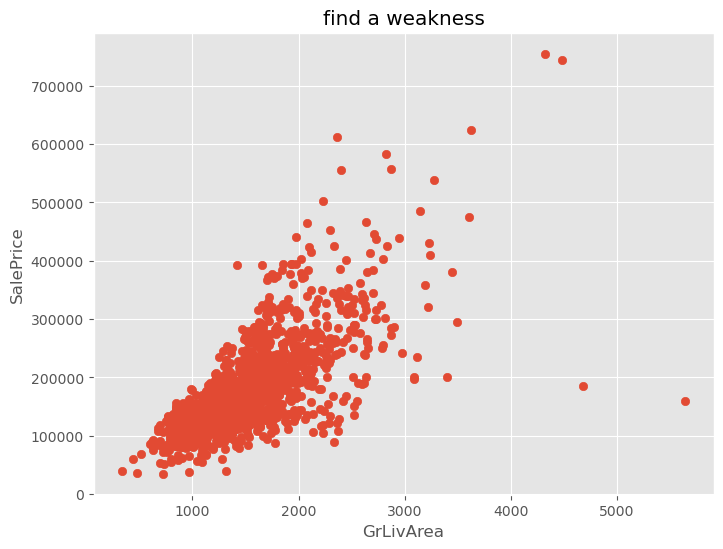

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(x=train['GrLivArea'], y=train['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('find a weakness')
plt.show()

In [5]:
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index

print(f"准备删除的离群点索引: {outliers}")

准备删除的离群点索引: Index([523, 1298], dtype='int64')
